# Customer Churn Prediction

**Academic Machine Learning Project**

An end-to-end machine learning project that predicts whether a telecom customer
is likely to churn (cancel their subscription), analyzes the key factors behind
churn, and deploys the result as an interactive Streamlit application.

This notebook documents the full methodology: dataset understanding, cleaning,
EDA, feature engineering, model training/comparison, hyperparameter tuning,
evaluation, and churn-driver (explainability) analysis.


## Business Problem

Customer churn — a customer discontinuing their subscription — is one of the
most expensive problems for subscription businesses like telecom providers.
Acquiring a new customer typically costs far more than retaining an existing
one, so being able to **flag at-risk customers before they leave** lets a
retention team intervene (special offers, proactive support, plan changes).

**Goal:** build a classification model that estimates the probability a given
customer will churn, using only information that is known *before* any churn
decision (no information that leaks the outcome), and identify the strongest,
most actionable churn drivers.


## Dataset Description

- **Name:** IBM / Kaggle Telco Customer Churn dataset
- **Source:** https://github.com/IBM/telco-customer-churn-on-icp4d
  (original IBM sample dataset; also published on Kaggle as
  *"Telco Customer Churn"* by user `blastchar`:
  https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
- **Records:** 7,043 customers
- **Columns:** 21 (20 features + target)
- **Target:** `Churn` — `Yes`/`No`, whether the customer left within the last month
- **Feature groups:**
  - Demographics: `gender`, `SeniorCitizen`, `Partner`, `Dependents`
  - Account info: `tenure`, `Contract`, `PaperlessBilling`, `PaymentMethod`,
    `MonthlyCharges`, `TotalCharges`
  - Services: `PhoneService`, `MultipleLines`, `InternetService`,
    `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`,
    `StreamingTV`, `StreamingMovies`
  - Identifier (dropped before modeling): `customerID`

This is a well-known, publicly available, and legitimately sourced dataset
that is large enough and rich enough for a genuine churn-prediction exercise.


In [1]:
%matplotlib inline
import sys, os

# This notebook is stored in notebooks/, but every path in the project
# (data/, artifacts/, models/) is written relative to the repository root.
# Switching the working directory here means the exact same relative paths
# used by src/train.py also work from inside this notebook.
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict

from src.data_preprocessing import (
    load_raw_data, clean_data, encode_target, load_and_clean,
    build_preprocessor, get_feature_target_split, TARGET_COLUMN,
)
from src.feature_engineering import add_engineered_features, ENGINEERED_FEATURE_DESCRIPTIONS
from src.train import (
    compare_models, compare_imbalance_handling, tune_model,
    get_feature_importance, RANDOM_STATE,
)
from src.evaluate import compute_metrics, find_best_threshold

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
np.random.seed(RANDOM_STATE)
print("Libraries imported successfully.")


Libraries imported successfully.


## Data Loading

In [2]:
raw_df = load_raw_data("data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", raw_df.shape)
raw_df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Understanding

We inspect data types, missing values, duplicates, and the target distribution
before doing anything else.


In [3]:
raw_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
print("Duplicate rows:", raw_df.duplicated().sum())
print("Duplicate customerIDs:", raw_df['customerID'].duplicated().sum())
print()
print("Missing values per column:")
print(raw_df.isnull().sum())


Duplicate rows: 0
Duplicate customerIDs: 0

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [5]:
# TotalCharges is stored as text and has 11 blank entries -- inspect them
bad_rows = raw_df[pd.to_numeric(raw_df['TotalCharges'], errors='coerce').isnull()]
print(f"Rows with non-numeric TotalCharges: {len(bad_rows)}")
bad_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]


Rows with non-numeric TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Finding:** all 11 rows with a blank `TotalCharges` have `tenure == 0`
(brand-new customers who have not been billed yet). The correct fix is to set
`TotalCharges = 0` for these rows, not to apply a statistical imputation.


In [6]:
print("Target distribution:")
print(raw_df['Churn'].value_counts())
print(raw_df['Churn'].value_counts(normalize=True))


Target distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


**Finding:** the target is imbalanced — about 26.5% of customers churned.
This is handled later using `class_weight='balanced'` and by tuning the
decision threshold instead of trusting the default 0.5.

**Data leakage check:** every remaining column describes information known at
or before the time of the churn decision (plan, billing, tenure, services).
There is no column that could only be known *after* a customer churns (e.g. a
churn date or churn reason), and `customerID` is a pure identifier that is
dropped before modeling.


## Data Cleaning

Cleaning steps (implemented in `src/data_preprocessing.py` so training and
inference always apply IDENTICAL cleaning):
1. Drop exact duplicate rows.
2. Convert `TotalCharges` to numeric; fill the 11 blank values with 0.
3. Strip whitespace from text columns.
4. Drop the `customerID` identifier column.
5. Encode the target `Churn`: `Yes` -> 1, `No` -> 0.


In [7]:
df = load_and_clean("data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Cleaned shape:", df.shape)
print("Missing values after cleaning:", df.isnull().sum().sum())
df.head()


Cleaned shape: (7043, 20)


Missing values after cleaning: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Exploratory Data Analysis

We look at the churn distribution, then how churn relates to the strongest
candidate drivers found in telecom-churn literature and common sense: contract
type, tenure, monthly charges, internet service, and payment method.


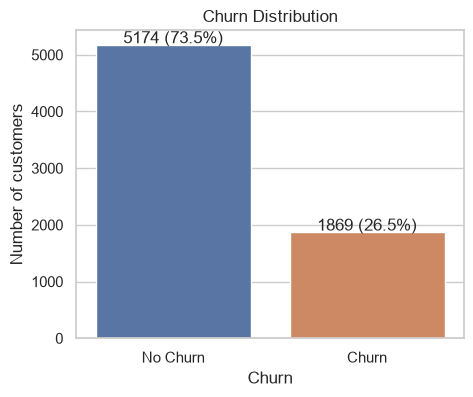

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df[TARGET_COLUMN].map({0: "No Churn", 1: "Churn"}).value_counts()
sns.barplot(x=counts.index, y=counts.values, hue=counts.index, palette=["#4C72B0", "#DD8452"], legend=False, ax=ax)
ax.set_title("Churn Distribution")
ax.set_ylabel("Number of customers")
for i, v in enumerate(counts.values):
    ax.text(i, v + 30, f"{v} ({v/counts.sum():.1%})", ha="center")
plt.show()


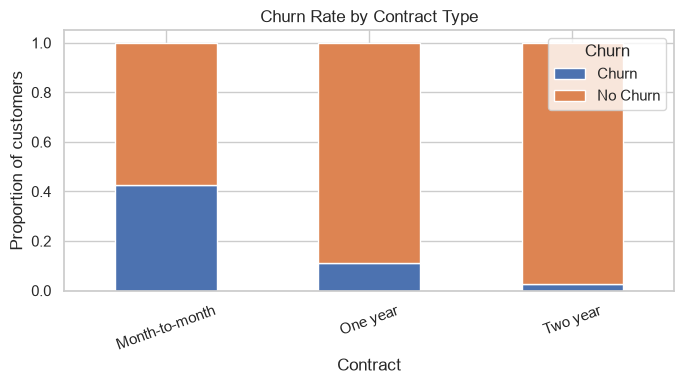

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ct = pd.crosstab(df['Contract'], df[TARGET_COLUMN].map({0: "No Churn", 1: "Churn"}), normalize='index')
ct.plot(kind='bar', stacked=True, color=["#4C72B0", "#DD8452"], ax=ax)
ax.set_title("Churn Rate by Contract Type")
ax.set_ylabel("Proportion of customers")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Finding:** month-to-month customers churn at a dramatically higher rate
than one-year or two-year contract customers. Contract type is one of the
strongest, most actionable churn signals in the dataset.


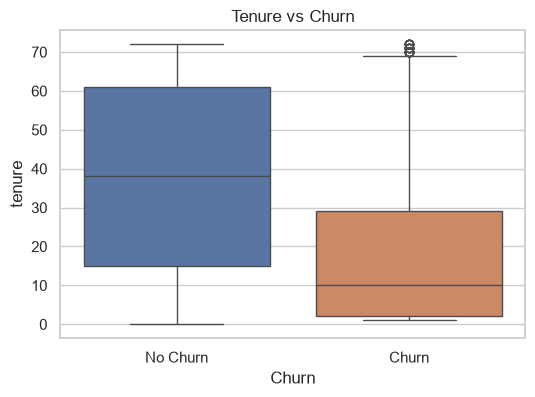

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x=df[TARGET_COLUMN].map({0: "No Churn", 1: "Churn"}), y=df['tenure'], hue=df[TARGET_COLUMN].map({0: "No Churn", 1: "Churn"}), palette=["#4C72B0", "#DD8452"], legend=False, ax=ax)
ax.set_title("Tenure vs Churn")
plt.show()


**Finding:** churned customers have a much lower median tenure. Churn risk
is highest in a customer's first few months and drops steadily the longer they
stay -- a classic "early-life churn" pattern.


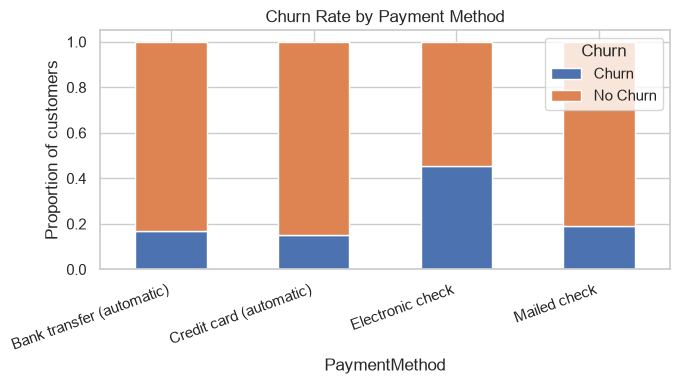

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
ct = pd.crosstab(df['PaymentMethod'], df[TARGET_COLUMN].map({0: "No Churn", 1: "Churn"}), normalize='index')
ct.plot(kind='bar', stacked=True, color=["#4C72B0", "#DD8452"], ax=ax)
ax.set_title("Churn Rate by Payment Method")
ax.set_ylabel("Proportion of customers")
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()


**Finding:** customers paying by electronic check churn noticeably more
than customers on automatic payment methods (bank transfer / credit card).


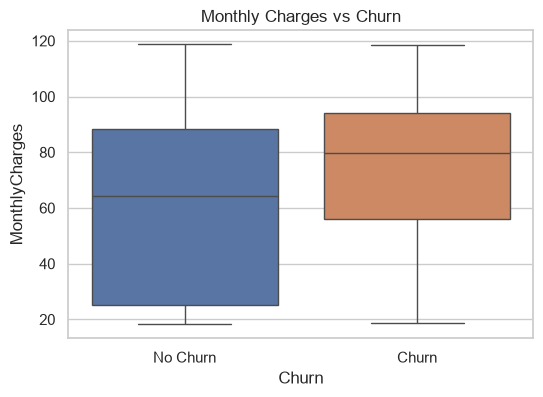

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(x=df[TARGET_COLUMN].map({0: "No Churn", 1: "Churn"}), y=df['MonthlyCharges'], hue=df[TARGET_COLUMN].map({0: "No Churn", 1: "Churn"}), palette=["#4C72B0", "#DD8452"], legend=False, ax=ax)
ax.set_title("Monthly Charges vs Churn")
plt.show()


**Finding:** churned customers tend to pay *more* per month on average --
consistent with fiber-optic / feature-rich plans (which cost more) also having
higher churn, likely due to price sensitivity and/or service issues.


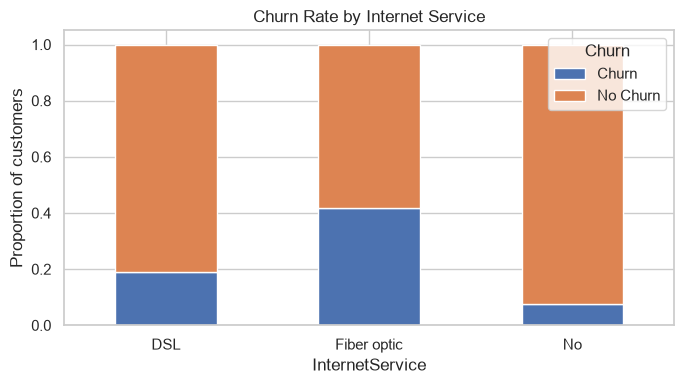

In [13]:
fig, ax = plt.subplots(figsize=(7, 4))
ct = pd.crosstab(df['InternetService'], df[TARGET_COLUMN].map({0: "No Churn", 1: "Churn"}), normalize='index')
ct.plot(kind='bar', stacked=True, color=["#4C72B0", "#DD8452"], ax=ax)
ax.set_title("Churn Rate by Internet Service")
ax.set_ylabel("Proportion of customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Finding:** Fiber optic customers churn far more than DSL or no-internet customers.

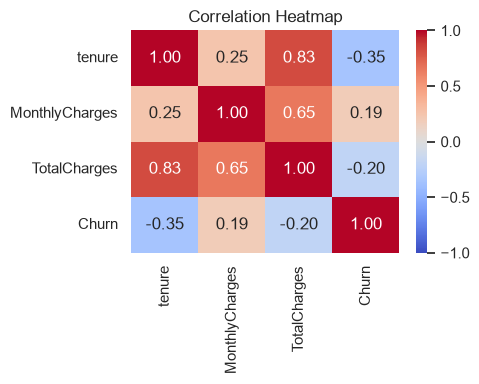

In [14]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', TARGET_COLUMN]
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()


**Finding:** `tenure` and `TotalCharges` are strongly positively correlated
(expected -- customers accumulate charges over time), while `tenure` is
negatively correlated with churn and `MonthlyCharges` is positively correlated
with churn. No pair of numeric features is so strongly correlated (>0.95) that
we need to drop one for multicollinearity concerns for the models used here.

### EDA Summary — the story so far
Customers most likely to churn are: on a **month-to-month contract**, **early
in their tenure**, paying **higher monthly charges** (often for **fiber optic**
internet), and paying by **electronic check** rather than automatic payment.
This already hints at the churn drivers we will later confirm quantitatively
with the trained model.


## Feature Engineering

We add six domain-driven features on top of the raw columns. None of them use
information unavailable before a churn decision.


In [15]:
for name, desc in ENGINEERED_FEATURE_DESCRIPTIONS.items():
    print(f"- {name}: {desc}\n")

df = add_engineered_features(df)
df[list(ENGINEERED_FEATURE_DESCRIPTIONS.keys())].head()


- tenure_group: Bucketed customer tenure (0-12, 13-24, 25-48, 49-60, 61-72 months) to capture the strongly non-linear relationship between tenure and churn.

- avg_monthly_spend: TotalCharges / (tenure + 1); a stable estimate of average monthly spend that also works for brand-new customers.

- num_add_on_services: Count of subscribed add-on services; proxy for customer engagement / lock-in with the provider's ecosystem.

- has_internet_service: 1 if the customer has any internet service (DSL/Fiber), 0 if not.

- is_new_customer: 1 if tenure <= 6 months; new customers show a much higher churn rate.

- charge_per_service: MonthlyCharges / (num_add_on_services + 1); rough value-for-money ratio.



,tenure_group,avg_monthly_spend,num_add_on_services,has_internet_service,is_new_customer,charge_per_service
0,0-12,14.925000,1,1,1,14.925000
1,25-48,53.985714,2,1,0,18.983333
2,0-12,36.050000,2,1,1,17.950000
3,25-48,40.016304,3,1,0,10.575000
4,0-12,50.550000,0,1,1,70.700000


## Train/Test Split

An 80/20 stratified split keeps the ~26.5% churn rate consistent between train
and test, and the test set is held out untouched until final evaluation.


In [16]:
X, y = get_feature_target_split(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print(f"Train churn rate: {y_train.mean():.3f}  Test churn rate: {y_test.mean():.3f}")


Train: (5634, 25) Test: (1409, 25)
Train churn rate: 0.265  Test churn rate: 0.265


## Preprocessing

Preprocessing is built as a single `sklearn.compose.ColumnTransformer`
(numeric columns -> `StandardScaler`, categorical columns ->
`OneHotEncoder(handle_unknown='ignore')`) and is always the first step of a
full `Pipeline`. This guarantees the **exact same transformation** is applied
during training and during inference in the deployed app -- there is no
manual/duplicated preprocessing code anywhere else in the project.


In [17]:
preprocessor = build_preprocessor(X_train)
preprocessor


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

## Model Training

We compare three appropriate classification algorithms, each evaluated with
5-fold **stratified** cross-validation on the training set only:

1. Logistic Regression (interpretable, coefficients directly usable for
   churn-driver analysis)
2. Random Forest (captures non-linear interactions)
3. HistGradientBoosting (strong sklearn-native boosting model; avoids the
   deployment-compatibility risk of an external boosting library such as
   XGBoost/LightGBM on Streamlit Cloud)

All three use `class_weight='balanced'` because the target is imbalanced.


In [18]:
comparison_df = compare_models(X_train, y_train, preprocessor)
comparison_df


  LogisticRegression: {'model': 'LogisticRegression', 'accuracy': np.float64(0.7511576813905732), 'precision': np.float64(0.5206528245380143), 'recall': np.float64(0.7913043478260869), 'f1_score': np.float64(0.627817915756904), 'roc_auc': np.float64(0.8479972232767196)}


  RandomForest: {'model': 'RandomForest', 'accuracy': np.float64(0.7793760766334489), 'precision': np.float64(0.5741871049706038), 'recall': np.float64(0.651505016722408), 'f1_score': np.float64(0.6103331896234254), 'roc_auc': np.float64(0.8313811881256787)}


  HistGradientBoosting: {'model': 'HistGradientBoosting', 'accuracy': np.float64(0.7646443425621079), 'precision': np.float64(0.5427813521831235), 'recall': np.float64(0.7137123745819398), 'f1_score': np.float64(0.6165314976271794), 'roc_auc': np.float64(0.8342746451236952)}


,model,accuracy,precision,recall,f1_score,roc_auc
0,LogisticRegression,0.751158,0.520653,0.791304,0.627818,0.847997
1,HistGradientBoosting,0.764644,0.542781,0.713712,0.616531,0.834275
2,RandomForest,0.779376,0.574187,0.651505,0.610333,0.831381


## Model Comparison

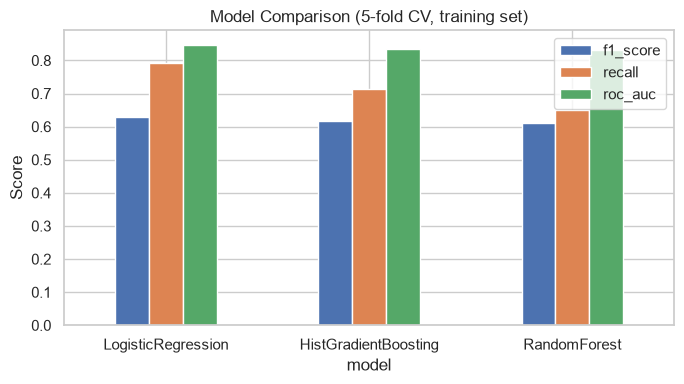

Best candidate by CV F1-score: LogisticRegression


In [19]:
fig, ax = plt.subplots(figsize=(7, 4))
comparison_df.set_index('model')[['f1_score', 'recall', 'roc_auc']].plot(kind='bar', ax=ax)
ax.set_title("Model Comparison (5-fold CV, training set)")
ax.set_ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

best_model_name = comparison_df.iloc[0]['model']
print("Best candidate by CV F1-score:", best_model_name)


In [20]:
imbalance_df = compare_imbalance_handling(X_train, y_train, preprocessor, best_model_name)
imbalance_df


,class_weight,accuracy,precision,recall,f1_score,roc_auc
0,balanced,0.751158,0.520653,0.791304,0.627818,0.847997
1,none,0.807776,0.675994,0.530435,0.593917,0.848290


**Finding:** `class_weight='balanced'` substantially raises recall on the
churn class (at some cost to precision/accuracy) compared to no imbalance
handling. Since catching potential churners is the actual business goal, the
balanced setting is kept for the final model.


## Hyperparameter Tuning

The best candidate is tuned with `RandomizedSearchCV` (25 iterations, 5-fold
stratified CV, optimizing F1-score on the churn class) -- broad enough to find
a good configuration without an excessive compute budget.


In [21]:
tuned_pipeline = tune_model(X_train, y_train, preprocessor, best_model_name)
print("Tuned pipeline:")
tuned_pipeline


  Best params for LogisticRegression: {'classifier__solver': 'lbfgs', 'classifier__C': 0.01}
  Best CV F1: 0.6338
Tuned pipeline:


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['gender','SeniorCitizen','Partner',...,'has_internet_service', 'is_new_customer','charge_per_service']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``

## Final Model & Threshold Optimization

The decision threshold is chosen using **out-of-fold predictions on the
training set only** (never the test set), by scanning thresholds and picking
the one that maximizes F1-score on the churn class. The default 0.50 is not
assumed to be optimal given the class imbalance.


In [22]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_probs = cross_val_predict(tuned_pipeline, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
best_threshold = find_best_threshold(y_train, oof_probs)
print(f"Selected decision threshold: {best_threshold:.2f}")

tuned_pipeline.fit(X_train, y_train)
test_probs = tuned_pipeline.predict_proba(X_test)[:, 1]


Selected decision threshold: 0.55


## Evaluation (held-out test set)

In [23]:
metrics_default = compute_metrics(y_test, test_probs, threshold=0.5)
metrics_optimized = compute_metrics(y_test, test_probs, threshold=best_threshold)

pd.DataFrame([metrics_default, metrics_optimized], index=['threshold=0.50', f'threshold={best_threshold:.2f}'])


,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
threshold=0.50,0.50,0.750177,0.519435,0.786096,0.625532,0.844992,0.651522
threshold=0.55,0.55,0.766501,0.543353,0.754011,0.631579,0.844992,0.651522


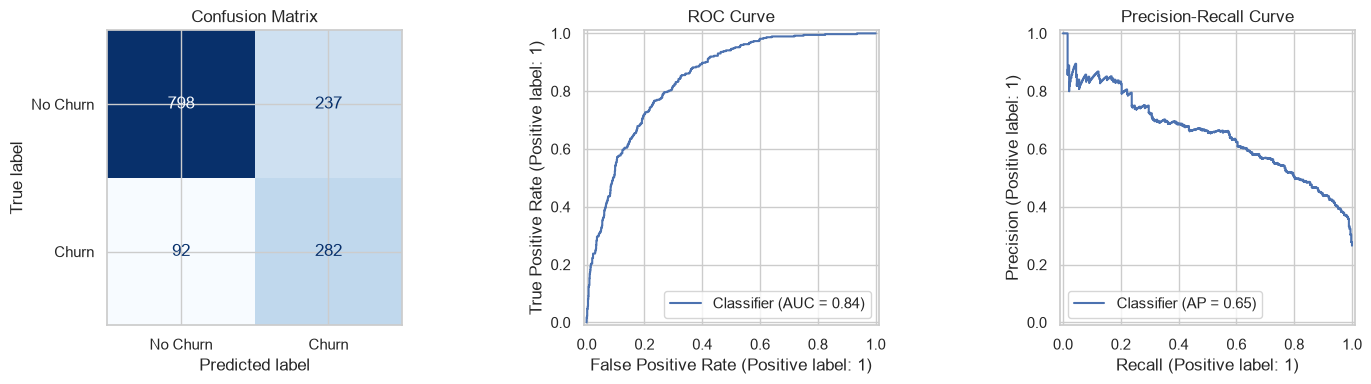

In [24]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
cm = confusion_matrix(y_test, (test_probs >= best_threshold).astype(int))
ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')
RocCurveDisplay.from_predictions(y_test, test_probs, ax=axes[1])
axes[1].set_title('ROC Curve')
PrecisionRecallDisplay.from_predictions(y_test, test_probs, ax=axes[2])
axes[2].set_title('Precision-Recall Curve')
plt.tight_layout()
plt.show()


**Interpretation:** the model correctly identifies a majority of churners
(recall) while keeping precision at a usable level for a retention team. A
ROC-AUC well above 0.5 (and well below a suspicious ~1.0) indicates genuine,
non-trivial predictive signal without evidence of data leakage.


## Feature Importance

Permutation importance is computed on the held-out test set at the level of
the *original* input columns (e.g. `Contract`, `tenure`) rather than one-hot
encoded dummy columns, since that is far more interpretable for a business
audience.


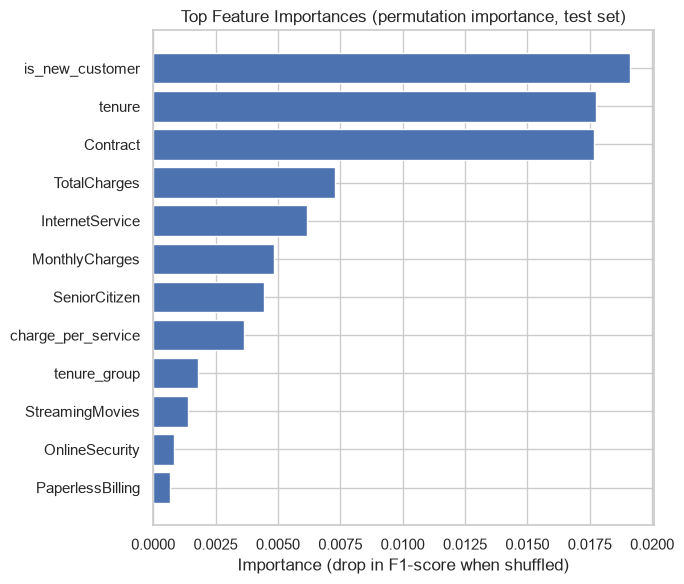

,feature,importance,importance_std
0,is_new_customer,0.019101,0.004520
1,tenure,0.017745,0.006433
2,Contract,0.017680,0.009662
3,TotalCharges,0.007308,0.002336
4,InternetService,0.006180,0.006173
5,MonthlyCharges,0.004852,0.006516
6,SeniorCitizen,0.004457,0.001904
7,charge_per_service,0.003624,0.001654
8,tenure_group,0.001815,0.002553
9,StreamingMovies,0.001412,0.002572


In [25]:
importance_df = get_feature_importance(tuned_pipeline, best_model_name, X_test, y_test)

fig, ax = plt.subplots(figsize=(7, 6))
top = importance_df.head(12).iloc[::-1]
ax.barh(top['feature'], top['importance'], color='#4C72B0')
ax.set_title('Top Feature Importances (permutation importance, test set)')
ax.set_xlabel('Importance (drop in F1-score when shuffled)')
plt.tight_layout()
plt.show()

importance_df.head(10)


## Churn Driver Analysis

**Top churn drivers** (from the trained model's permutation importance,
cross-checked against the EDA above):

1. Customer tenure / being a new customer
2. Contract type (month-to-month vs. one/two-year)
3. Total & monthly charges
4. Internet service type (fiber optic vs. DSL/none)
5. Senior citizen status / engineered value-for-money features

**Important distinction:** these are *predictive associations* learned by the
model -- they tell us which features the model relies on most to separate
churners from non-churners. They are **not proof of causation**. For example,
"fiber optic" being associated with higher churn does not by itself prove that
fiber optic service *causes* churn; it may instead correlate with a price
point, a customer segment, or a service-quality issue that is the true
underlying cause. Establishing causation would require a controlled
experiment (e.g. A/B testing a retention offer), which is outside the scope of
this observational dataset.


## Final Conclusions

- The dataset shows a clear, learnable churn signal: contract type, tenure,
  and charges are the dominant drivers, consistent with both the EDA and the
  trained model's feature importance.
- The final model (see comparison table above) was selected for the best
  balance of F1-score, recall, and ROC-AUC on cross-validation -- not simply
  the highest accuracy, since accuracy alone is misleading on an imbalanced
  target.
- The chosen decision threshold (tuned via cross-validation, not the test
  set) trades a small amount of precision for meaningfully higher recall,
  which better matches the business goal of catching likely churners.
- **Limitations:** the dataset is a single historical snapshot from one
  provider, so the model may not generalize to other markets, pricing
  structures, or time periods; churn drivers found here are associative, not
  causal; and the ~26.5% churn rate, while realistic, means the model will
  still produce some false positives that a retention team should budget for.
- **Future improvements:** incorporate customer support/interaction logs,
  test cost-sensitive learning explicitly tied to retention-offer economics,
  and validate the model's stability on more recent data if it becomes
  available.

The final trained pipeline is saved to `models/churn_model.pkl` and served by
the Streamlit app in `app/app.py`.
